# Кластеризация

Метан ответственен примерно за 30% повышения глобальной температуры со времён промышленной революции, и быстрое и устойчивое сокращение выбросов метана имеет ключевое значение для ограничения глобального потепления в краткосрочной перспективе и улучшения качества воздуха. На энергетический сектор, включая нефть, природный газ, уголь и биоэнергетику, приходится почти 40% выбросов метана, связанных с деятельностью человека.

In [4]:
import pandas as pd

filename = './data/em.csv'
cat_cols = ['region', 'type', 'segment', 'reason']
base_cols = ['emissions']
cols = [*cat_cols, *base_cols]
dtype_dict = {col: str for col in cat_cols if col in cols}
data = pd.read_csv(filename, usecols=cols, on_bad_lines='skip', dtype=dtype_dict)

data.dropna(inplace=True)

data

,region,emissions,type,segment,reason
0,Africa,257.611206,Agriculture,Total,All
1,Africa,0.052000,Energy,Bioenergy,All
2,Africa,130.798996,Energy,Gas pipelines and LNG facilities,Fugitive
3,Africa,69.741898,Energy,Gas pipelines and LNG facilities,Vented
4,Africa,213.987000,Energy,Onshore gas,Fugitive
...,...,...,...,...,...
1543,World,3102.500000,Energy,Satellite-detected large oil and gas emissions,All
1544,World,30296.500000,Energy,Steam coal,All
1545,World,133350.984375,Energy,Total,All
1546,World,9737.874023,Other,Total,All


In [5]:
data.head()

,region,emissions,type,segment,reason
0,Africa,257.611206,Agriculture,Total,All
1,Africa,0.052000,Energy,Bioenergy,All
2,Africa,130.798996,Energy,Gas pipelines and LNG facilities,Fugitive
3,Africa,69.741898,Energy,Gas pipelines and LNG facilities,Vented
4,Africa,213.987000,Energy,Onshore gas,Fugitive


In [6]:
import numpy as np
mappings = {}

for col in cat_cols:
    u = np.unique(data[col])
    mappings[col] = {}
    for i in range(len(u)):
        mappings[col][i] = u[i]

for col in cat_cols:
    data[col] = pd.factorize(data[col])[0]

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   region     1548 non-null   int64  
 1   emissions  1548 non-null   float64
 2   type       1548 non-null   int64  
 3   segment    1548 non-null   int64  
 4   reason     1548 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 60.6 KB


In [7]:
data_stats = data.describe()
data_stats

,region,emissions,type,segment,reason
count,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000
mean,2.305556,643.255972,1.135659,3.675711,0.891473
std,2.108326,5566.238201,0.623558,3.273091,0.998307
min,0.000000,0.000459,0.000000,0.000000,0.000000
25%,0.000000,2.659361,1.000000,0.000000,0.000000
50%,2.000000,24.064669,1.000000,3.000000,1.000000
75%,3.250000,128.419594,1.000000,6.000000,2.000000
max,8.000000,141953.765625,3.000000,11.000000,3.000000


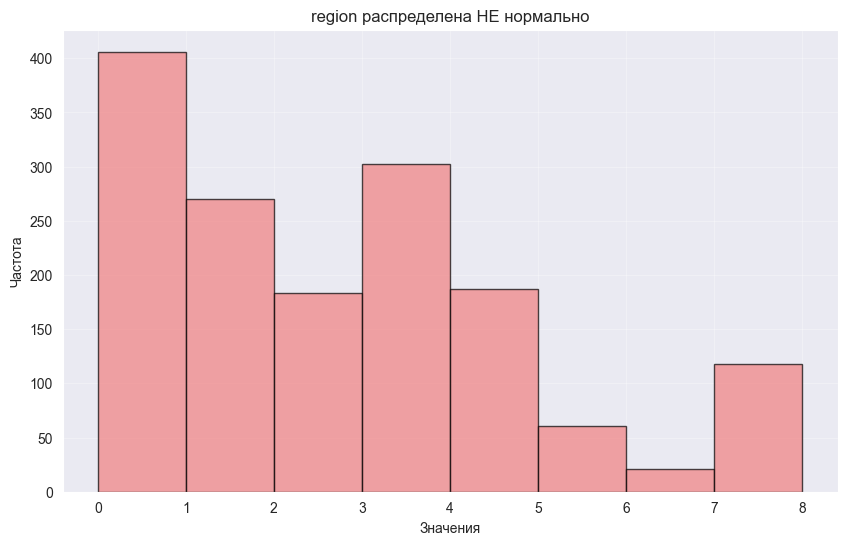

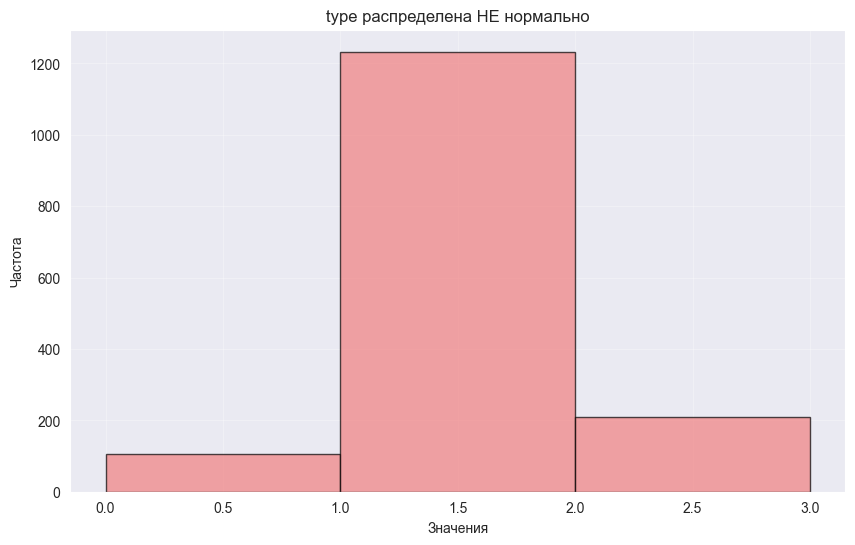

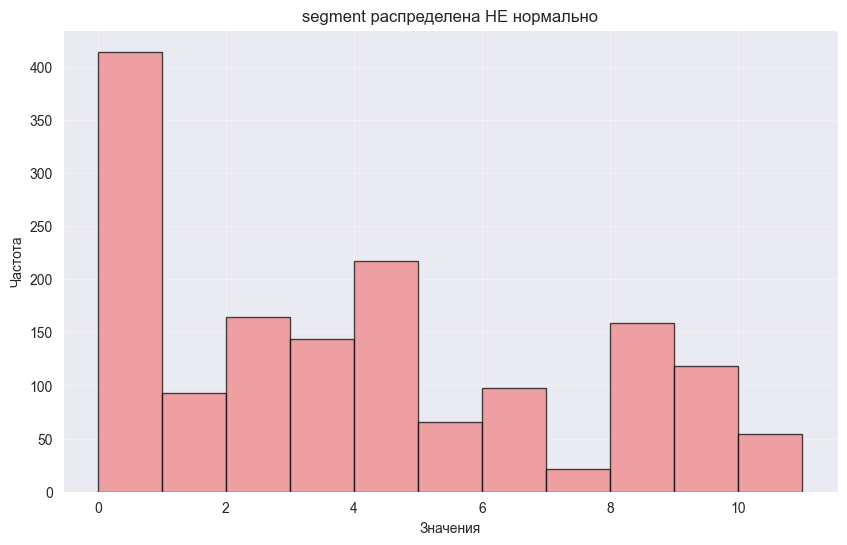

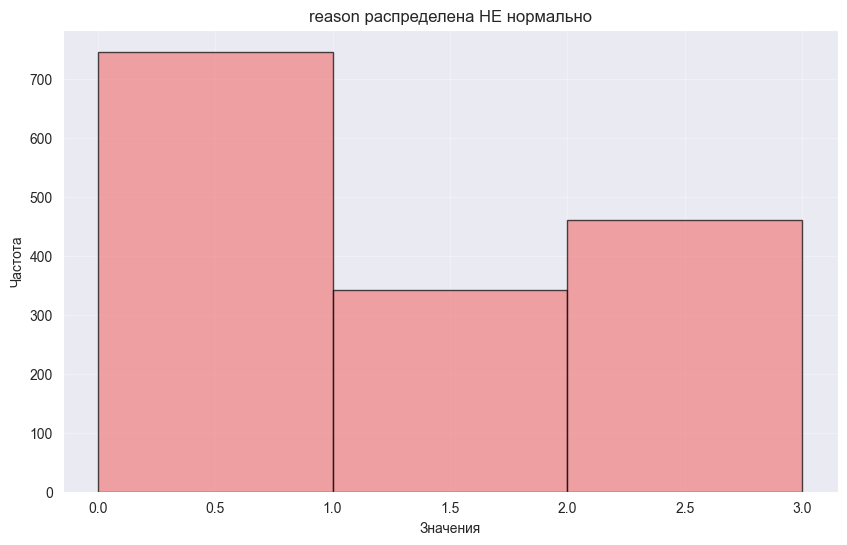

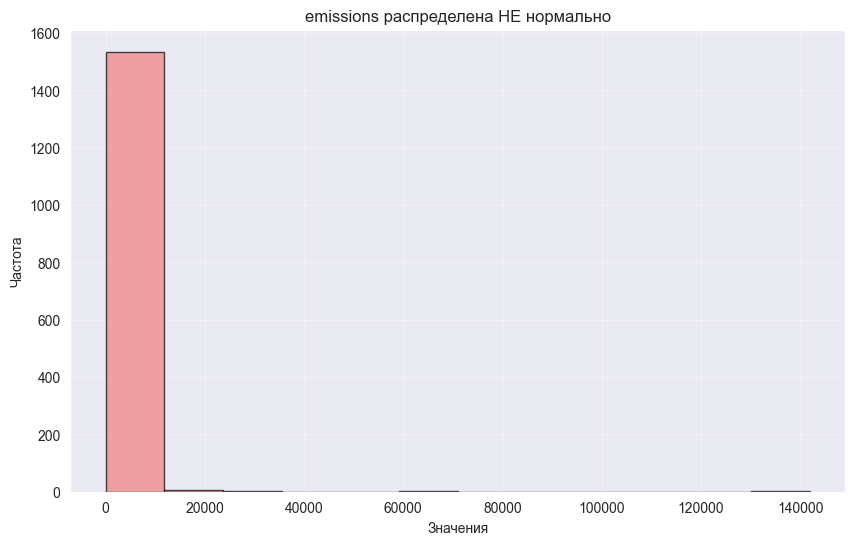

In [8]:
import matplotlib.pyplot as plt
from scipy import stats

for col in cols:
    _, p_value = stats.normaltest(data[col])

    plt.figure(figsize=(10, 6))
    plt.hist(data[col], bins='sturges', alpha=0.7, color='lightcoral', edgecolor='black')
    plt.title(f'{col} распределена{' НЕ' if p_value <= 0.05 else ''} нормально')
    plt.xlabel('Значения')
    plt.ylabel('Частота')
    plt.grid(alpha=0.3)
    plt.show()

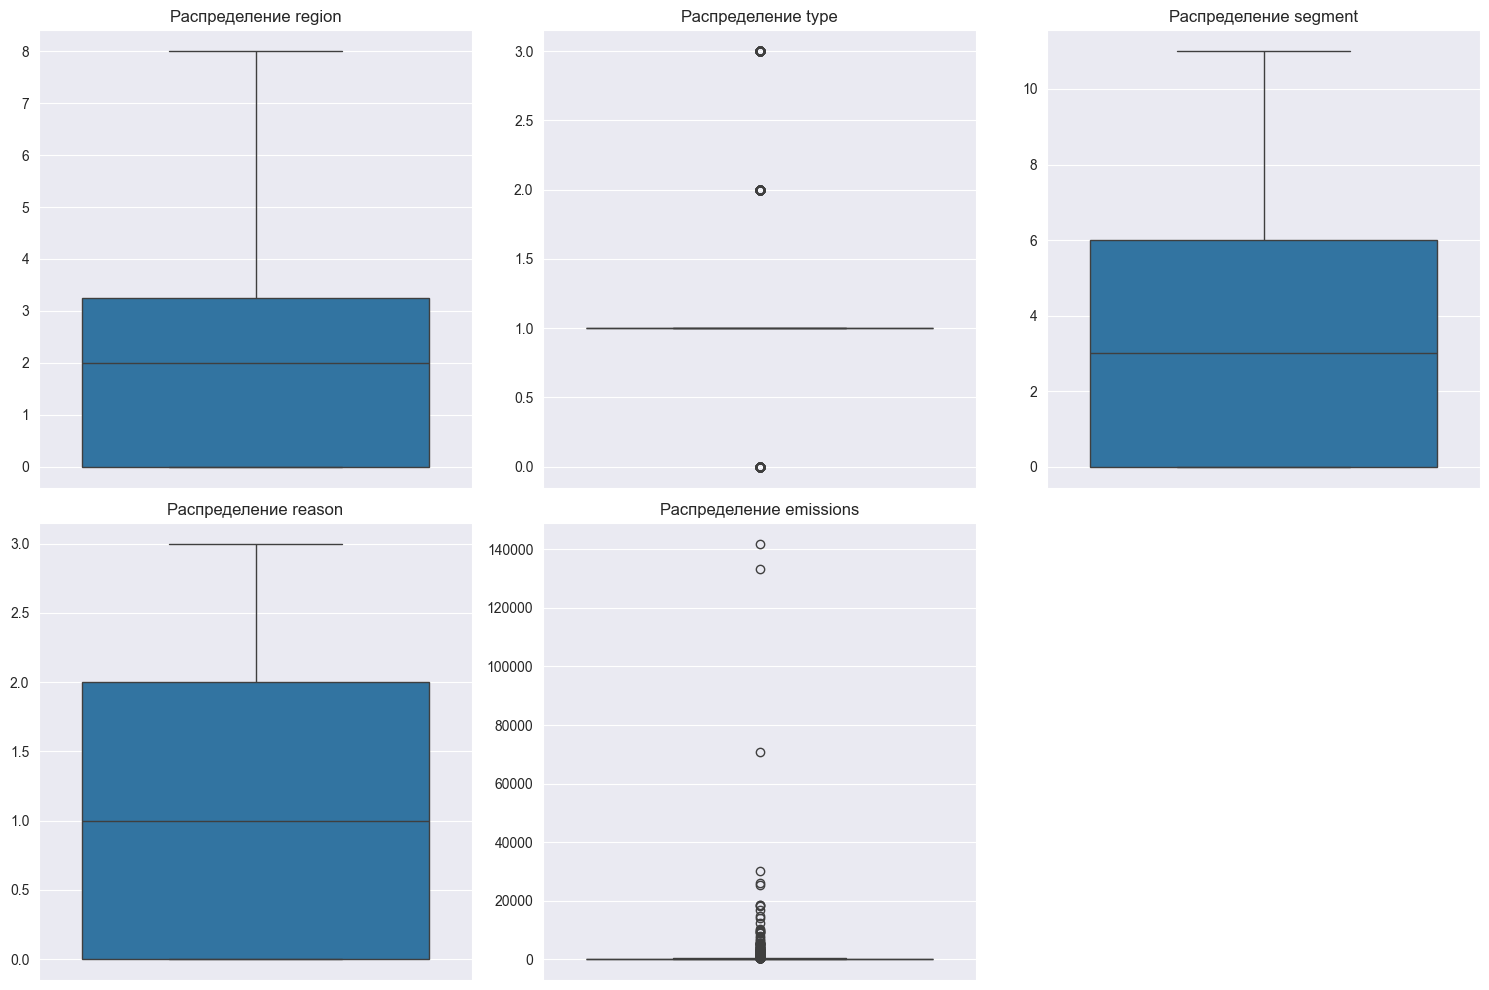

In [9]:
import seaborn as sns

n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for i, col in enumerate(cols):
    if i < len(axes):
        sns.boxplot(y=data[col], ax=axes[i])
        axes[i].set_title(f'Распределение {col}')
        axes[i].set_ylabel('')

# Скрываем пустые subplots
for i in range(len(cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [10]:
df_clean = data.copy()

for col in []:
    if col in data.columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        mask = (df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)
        df_clean = df_clean[mask]

print(f"Удалено {len(data) - len(df_clean)} строк с выбросами")
print(f"Осталось {len(df_clean)} строк из {len(data)}")

data = df_clean

Удалено 0 строк с выбросами
Осталось 1548 строк из 1548


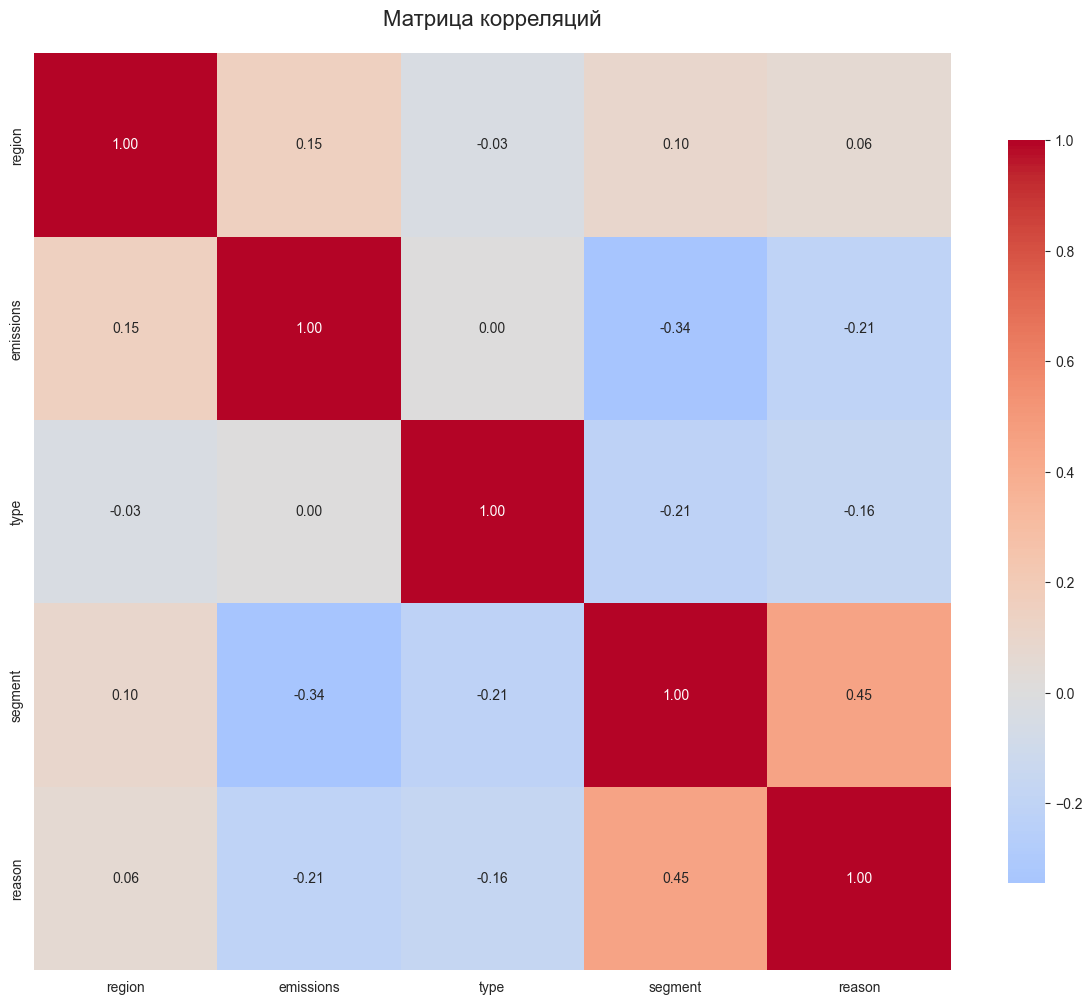

In [11]:
corr_matrix = data.corr(method='spearman')

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={"shrink": .8})

plt.title('Матрица корреляций', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [12]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

def hopkins_statistic(X_scaled, sample_ratio=0.1, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)

    X = np.array(X_scaled)
    n_samples, n_features = X.shape

    if np.isnan(X).any():
        raise ValueError("Данные содержат NaN значения")

    n_sample = max(2, int(sample_ratio * n_samples))

    sample_indices = np.random.choice(n_samples, n_sample, replace=False)
    X_sample = X_scaled[sample_indices]

    X_uniform = np.random.uniform(
        low=X_scaled.min(axis=0),
        high=X_scaled.max(axis=0),
        size=(n_sample, n_features)
    )

    nn_original = NearestNeighbors(n_neighbors=2, metric='euclidean')
    nn_original.fit(X_scaled)

    distances_original = []
    for point in X_sample:
        dists, _ = nn_original.kneighbors([point], n_neighbors=2)
        distances_original.append(dists[0, 1])

    nn_uniform = NearestNeighbors(n_neighbors=1, metric='euclidean')
    nn_uniform.fit(X_scaled)

    distances_uniform, _ = nn_uniform.kneighbors(X_uniform, n_neighbors=1)
    distances_uniform = distances_uniform.flatten()

    sum_original = np.sum(distances_original)
    sum_uniform = np.sum(distances_uniform)

    hopkins_stat = sum_uniform / (sum_uniform + sum_original)

    return hopkins_stat

X_initial = data
X = data

for column in X.columns:
    if (X[column] <= 0).any():
        min_val = X[column].min()
        if min_val <= 0:
            X[column] = X[column] + abs(min_val) + 1

X_log = np.log1p(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

hopkins_statistic(X_scaled, 0.1, 42)

np.float64(0.9259699124418015)

Выбран StandardScaler по следующим причинам:

- Сохраняет информацию о распределении
- Поддерживает статистические свойства
- Стандартный выбор для многих задач
- Интерпретируемость результатов

RobustScaler не подошел, потому что в датасете выбросы оказались не "шумом", а реальными данными. Поэтому если их убрать, качество кластеризации упадет

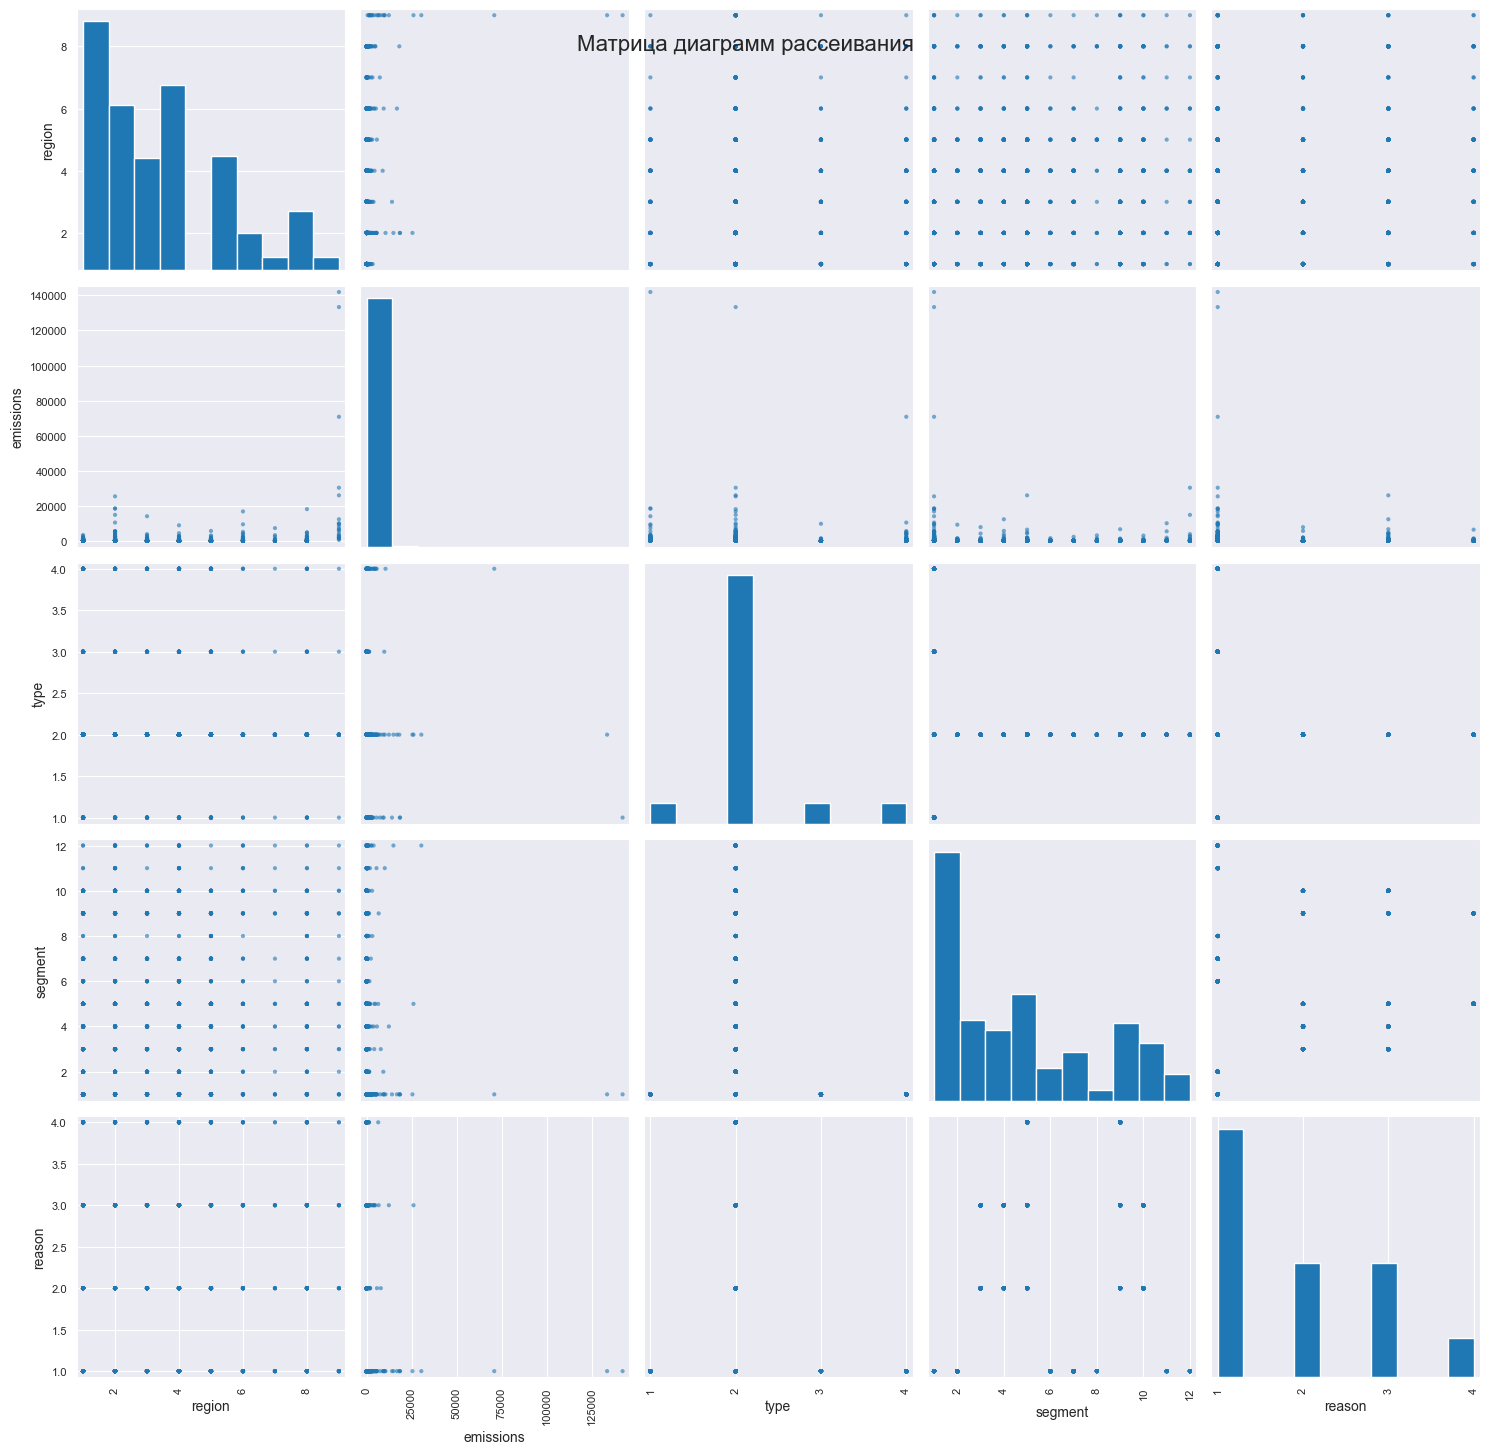

In [13]:
pd.plotting.scatter_matrix(data,
                          figsize=(15, 15),
                          alpha=0.6,
                          diagonal='hist',
                          grid=True)

plt.suptitle('Матрица диаграмм рассеивания', fontsize=16, y=0.95)
plt.tight_layout()
plt.show()

## Выбор методов

По диаграммам рассеивания нет возможности предположить о количестве кластеров и типе кластерной структуры.

**DBSCAN** был выбран по следующим причинам:
- Автоматическое определение числа кластеров
- Устойчивость к шуму (явное выделение выбросов)
- Способность находить кластеры произвольной формы
- Работает с кластерами разной плотности

Вторым методом стал **EM** (Gaussian Mixture)
- Мягкая кластеризация
- Учет неопределенности классификации
- Возможность моделировать разные формы
- Хорошо работает со смесями распределений

K-means нет смысла выбирать из-за отсутствия сферических кластеров, а иерархическая не подойдет, т.к. выбросы сильно искажают дендрограмму и нет явного механизма выделения шума

In [14]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

def plot_silhouette_analysis(labels, X_scaled=None, figsize=(10, 8)):
    if -1 in labels:
        valid_mask = labels != -1
        X_valid = X_scaled[valid_mask]
        labels_valid = labels[valid_mask]
        n_noise = np.sum(labels == -1)
    else:
        X_valid = X_scaled
        labels_valid = labels
        n_noise = 0

    n_clusters = len(np.unique(labels_valid))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(f'Анализ силуэтов для кластеризации\n'
                f'Кластеров: {n_clusters}, Шум: {n_noise} объектов',
                fontsize=14, fontweight='bold')

    silhouette_avg = silhouette_score(X_valid, labels_valid)
    sample_silhouette_values = silhouette_samples(X_valid, labels_valid)

    y_lower = 10
    cluster_silhouette_avgs = []

    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[labels_valid == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i),
                fontweight='bold', fontsize=12)

        cluster_avg = np.mean(ith_cluster_silhouette_values)
        cluster_silhouette_avgs.append(cluster_avg)

        y_lower = y_upper + 10

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--",
                label=f'Средний силуэт: {silhouette_avg:.3f}')

    ax1.set_xlabel('Силуэтный коэффициент')
    ax1.set_ylabel('Кластер')
    ax1.set_yticks([])

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_valid) + (n_clusters + 1) * 10])
    ax1.legend(loc='upper right')

    clusters = list(range(n_clusters))
    colors = [cm.nipy_spectral(float(i) / n_clusters) for i in range(n_clusters)]

    bars = ax2.bar(clusters, cluster_silhouette_avgs, color=colors, alpha=0.7)
    ax2.axhline(y=silhouette_avg, color='red', linestyle='--',
                label=f'Общее среднее: {silhouette_avg:.3f}')

    for bar, value in zip(bars, cluster_silhouette_avgs):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

    ax2.set_xlabel('Кластер')
    ax2.set_ylabel('Средний силуэтный коэффициент')
    ax2.set_title('Средние силуэтные коэффициенты по кластерам')
    ax2.set_xticks(clusters)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nДЕТАЛЬНАЯ СТАТИСТИКА СИЛУЭТОВ:")
    print("=" * 40)
    print(f"Общий средний силуэтный коэффициент: {silhouette_avg:.3f}")
    print(f"Количество кластеров: {n_clusters}")

    if n_noise > 0:
        print(f"Шумовых объектов (не участвуют в анализе): {n_noise}")

    print(f"Размеры кластеров:")
    for cluster_num in range(len(np.unique(labels))):
        cluster_size = (labels == cluster_num).sum()
        print(f"  Кластер {cluster_num}: {cluster_size} объектов ({cluster_size/len(data)*100:.1f}%)")

    return silhouette_avg, cluster_silhouette_avgs

In [15]:
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score
)
from scipy.spatial.distance import cdist, pdist
import warnings
warnings.filterwarnings('ignore')

def calculate_internal_metrics(X, labels):
    metrics = {}

    unique_labels = np.unique(labels)

    if len(unique_labels) >= 2 and not all(labels == labels[0]):
        valid_mask = labels != -1 if -1 in labels else np.ones_like(labels, dtype=bool)
        if np.sum(valid_mask) > 0:
            X_valid = X[valid_mask]
            labels_valid = labels[valid_mask]
            if len(np.unique(labels_valid)) >= 2:
                metrics['Silhouette'] = silhouette_score(X_valid, labels_valid)

    if len(unique_labels) >= 2 and not all(labels == labels[0]):
        valid_mask = labels != -1 if -1 in labels else np.ones_like(labels, dtype=bool)
        if np.sum(valid_mask) > 0:
            X_valid = X[valid_mask]
            labels_valid = labels[valid_mask]
            if len(np.unique(labels_valid)) >= 2:
                metrics['Calinski-Harabasz'] = calinski_harabasz_score(X_valid, labels_valid)

    if len(unique_labels) >= 2 and not all(labels == labels[0]):
        valid_mask = labels != -1 if -1 in labels else np.ones_like(labels, dtype=bool)
        if np.sum(valid_mask) > 0:
            X_valid = X[valid_mask]
            labels_valid = labels[valid_mask]
            if len(np.unique(labels_valid)) >= 2:
                metrics['Davies-Bouldin'] = davies_bouldin_score(X_valid, labels_valid)

    if -1 in labels:
        valid_mask = labels != -1
        X_valid = X[valid_mask]
        labels_valid = labels[valid_mask]
    else:
        X_valid = X
        labels_valid = labels

    if len(X_valid) > 0 and len(np.unique(labels_valid)) >= 2:
        intra_distances = []
        for label in np.unique(labels_valid):
            cluster_points = X_valid[labels_valid == label]
            if len(cluster_points) > 1:
                distances = pdist(cluster_points)
                intra_distances.append(np.mean(distances))
        if intra_distances:
            metrics['Avg_Intra_Cluster_Dist'] = np.mean(intra_distances)
            metrics['Std_Intra_Cluster_Dist'] = np.std(intra_distances)

        inter_distances = []
        unique_labels_list = np.unique(labels_valid)
        for i in range(len(unique_labels_list)):
            for j in range(i+1, len(unique_labels_list)):
                points_i = X_valid[labels_valid == unique_labels_list[i]]
                points_j = X_valid[labels_valid == unique_labels_list[j]]
                distances = cdist(points_i, points_j)
                inter_distances.append(np.min(distances))
        if inter_distances:
            metrics['Min_Inter_Cluster_Dist'] = np.min(inter_distances)
            metrics['Avg_Inter_Cluster_Dist'] = np.mean(inter_distances)

    return metrics

In [16]:
from sklearn.cluster import DBSCAN

def get_silhouette(labels, X_scaled):
    if all(x == -1 for x in labels) or len(np.unique(labels)) < 2:
        return 0

    if -1 in labels:
        valid_mask = labels != -1
        X_valid = X_scaled[valid_mask]
        labels_valid = labels[valid_mask]
    else:
        X_valid = X_scaled
        labels_valid = labels

    if len(X_valid) < 2 or len(np.unique(labels_valid)) < 2:
        return 0

    return silhouette_score(X_valid, labels_valid)

min_samples_list = [5, 10, 15, 20]

res = []

for min_samples in min_samples_list:
    for i in range(15):
        dbscan = DBSCAN(eps=0.1 + i * 0.1, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_noise = np.sum(labels == -1)
        if not n_noise / len(data) > 0.05:
            res.append((0.1 + i * 0.1, min_samples, get_silhouette(labels, X_scaled)))


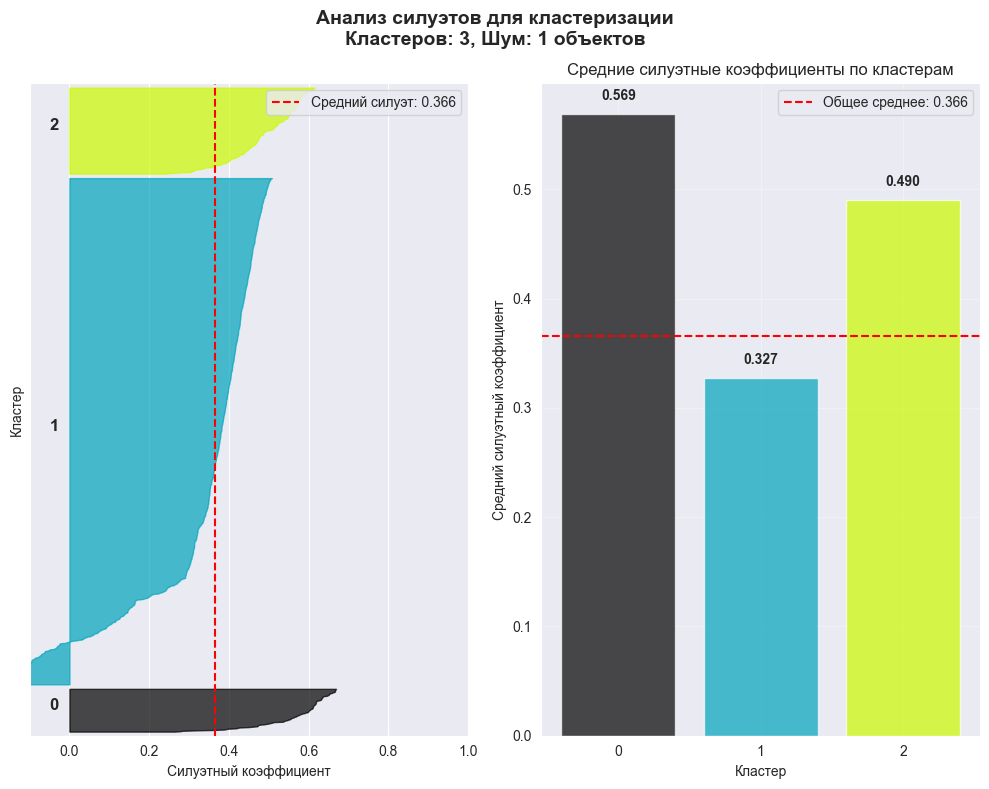


ДЕТАЛЬНАЯ СТАТИСТИКА СИЛУЭТОВ:
Общий средний силуэтный коэффициент: 0.366
Количество кластеров: 3
Шумовых объектов (не участвуют в анализе): 1
Размеры кластеров:
  Кластер 0: 105 объектов (6.8%)
  Кластер 1: 1232 объектов (79.6%)
  Кластер 2: 210 объектов (13.6%)
  Кластер 3: 0 объектов (0.0%)


{'Silhouette': 0.36552310457149445,
 'Calinski-Harabasz': 429.7662955069428,
 'Davies-Bouldin': 1.000839572047088,
 'Avg_Intra_Cluster_Dist': np.float64(2.0366860068235706),
 'Std_Intra_Cluster_Dist': np.float64(0.32874027672967393),
 'Min_Inter_Cluster_Dist': np.float64(1.5658549862568722),
 'Avg_Inter_Cluster_Dist': np.float64(2.515202405668361)}

In [17]:
eps, min_samples, _ = max(res, key=lambda x: x[2])

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

plot_silhouette_analysis(labels=labels, X_scaled=X_scaled)

calculate_internal_metrics(X_scaled, labels)

## Анализ метрик

- Silhouette = 0.3655 указывает на слабую, но существующую кластерную структуру. Кластеры различимы, но плохо отделены друг от друга.
- Calinski-Harabasz = 429 очень высокое значение => межкластерная дисперсия превышает внутрекластерную, что говорит о хорошем разделении кластеров, низкий Silhouette вероятно из-за несферической формы кластеров
- Davies-Bouldin = 1 на границе удовлетворительного. Кластеры имеют умеренную компактность и разделимость, сходство кластеров не критичное.
- Внутрикластерные расстояния: среднее расстояние 2, среднее отклонение ~16%, кластеры имеют хорошую компактность, точки расположены близко друг к другу
- Межкластерные расстояния: среднее 2.5, мин. 1.57, что говорит о том, что кластеры относительно разделены

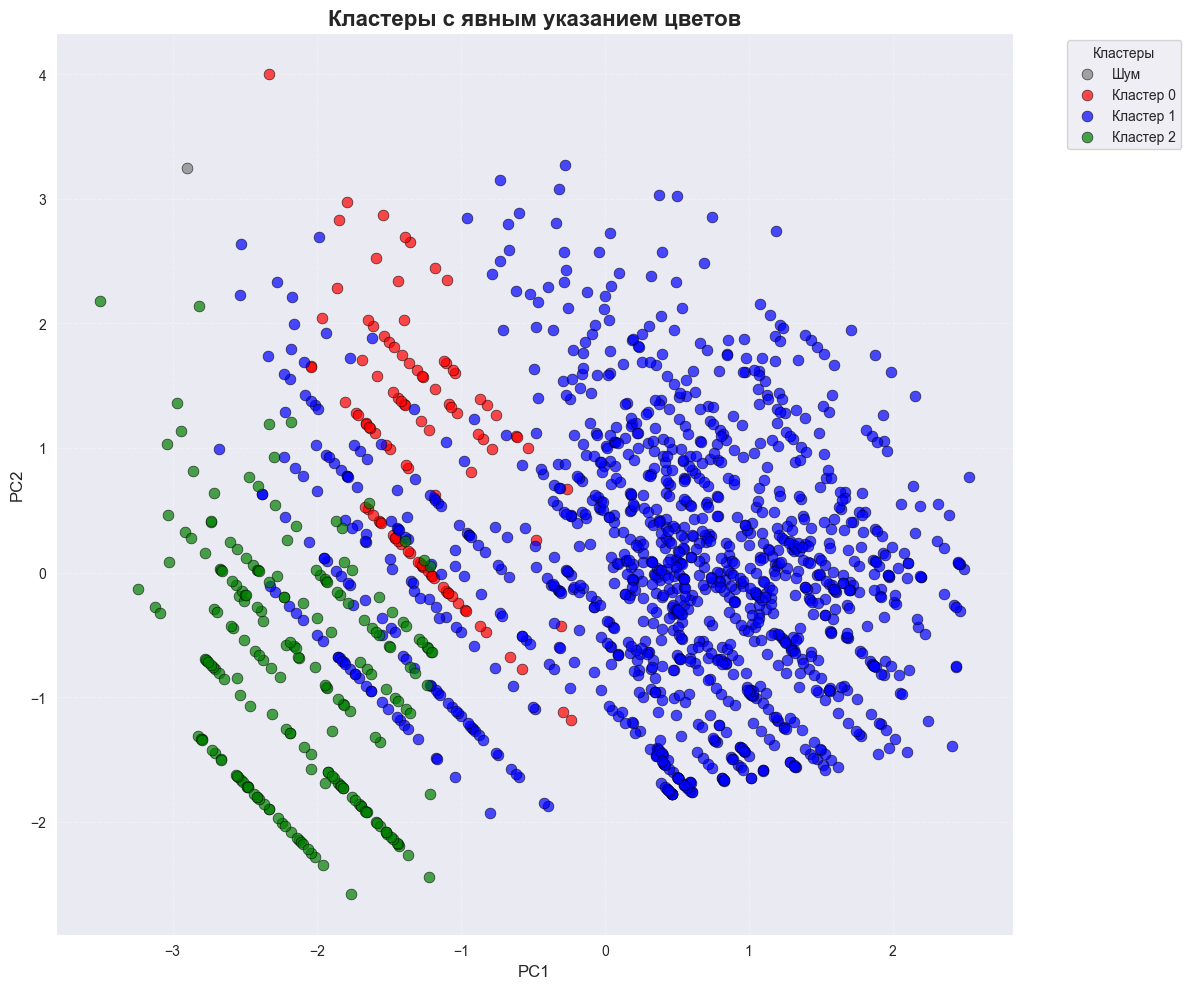

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

def get_scatter(X_pca, labels):
    cluster_colors = {
        -1: 'gray',
        0: 'red',
        1: 'blue',
        2: 'green'
    }

    plt.figure(figsize=(12, 10))

    unique_labels = np.unique(labels)

    for label in unique_labels:
        mask = labels == label

        color = cluster_colors.get(label, 'black')

        if label == -1:
            legend_label = 'Шум'
        else:
            legend_label = f'Кластер {label}'

        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            color=color,
            s=60,
            alpha=0.7,
            edgecolors='black',
            linewidths=0.5,
            label=legend_label
        )

    plt.title('Кластеры с явным указанием цветов', fontsize=16, fontweight='bold')
    plt.xlabel('PC1', fontsize=12)
    plt.ylabel('PC2', fontsize=12)
    plt.legend(title='Кластеры', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

get_scatter(X_pca, labels)

Видно, что красный и синий кластеры достаточно хорошо разделены, а зеленый находится между ними. Также в основном точки лежат на линиях. Это свидетельствует о том, что основное разделение на кластеры заключается в количестве выбросов и типа деятельности.

In [19]:
df_cluster = pd.DataFrame(X_initial).copy()
df_cluster["cluster"] = labels

cluster_profiles = df_cluster.groupby("cluster").mean()

print("=== Средние значения признаков по кластерам ===")
print(cluster_profiles.round(3))

pd.DataFrame(mappings)

=== Средние значения признаков по кластерам ===
         region   emissions  type  segment  reason
cluster                                           
-1        9.000  133350.984   2.0    1.000    1.00
 0        2.962    2788.180   1.0    1.000    1.00
 1        3.389     327.959   2.0    5.619    2.12
 2        2.962     788.596   3.5    1.000    1.00


,region,type,segment,reason
0,Africa,Agriculture,Bioenergy,All
1,Asia Pacific,Energy,Coking coal,Flared
2,Central and South America,Other,Gas pipelines and LNG facilities,Fugitive
3,Europe,Waste,Offshore gas,Vented
4,Middle East,NaN,Offshore oil,NaN
5,North America,NaN,Onshore gas,NaN
6,Other,NaN,Onshore oil,NaN
7,Russia & Caspian,NaN,Other from coal,NaN
8,World,NaN,Other from oil and gas,NaN
9,NaN,NaN,Satellite-detected large oil and gas emissions,NaN


Получилось 3 кластера по степени загрязнения - в первом загрязнение высокое, во втором воздух практически чистый, в третьем критические значения.

Регионы у кластеров смешаны, основное приходится на Америку.

Тип загрязнения у первого кластера - сельское хозяйство, у второго энергетика и третьего - мусор и др. Можно сделать вывод, что энергетика имеет наименьший вред.

Сегмент у второго кластера примерно на уровне Onshore gas, что соответствует смыслу типа "Энергетика"

Аналогично у второго кластера причина загрязнения ближе к Flared - сжигание, т.к. основная причина энергетика. У остальных кластеров с высоким загрязнением находятся все варианты.

## Анализ гиперпараметров

In [20]:
df = pd.DataFrame(res, columns=['eps', 'min_samples', 'silhouette_score'])
df

,eps,min_samples,silhouette_score
0,0.6,5,0.184022
1,0.7,5,0.225268
2,0.8,5,0.218500
3,0.9,5,0.270842
4,1.0,5,0.269576
5,1.1,5,0.269576
6,1.2,5,0.269576
7,1.3,5,0.288983
8,1.4,5,0.364773
9,1.5,5,0.364773


In [21]:
df.describe()

,eps,min_samples,silhouette_score
count,32.000000,32.000000,32.000000
mean,1.140625,11.718750,0.289039
std,0.249980,5.765495,0.049468
min,0.600000,5.000000,0.184022
25%,0.975000,5.000000,0.269396
50%,1.150000,10.000000,0.270597
75%,1.325000,15.000000,0.308191
max,1.500000,20.000000,0.365523


По результатам подбора видно, что при малом eps < 0.6 кластеров получается слишком много и появляются выбросы, чего подбор не допускает.

Также с увеличением n_samples увеличивается и eps, чтобы не допускать большого количества шума.

Наилучший результат показал большой eps=1.4 и n_samples=20, чтобы минимизировать влияние выбросов и не допускать большое количество шумов.

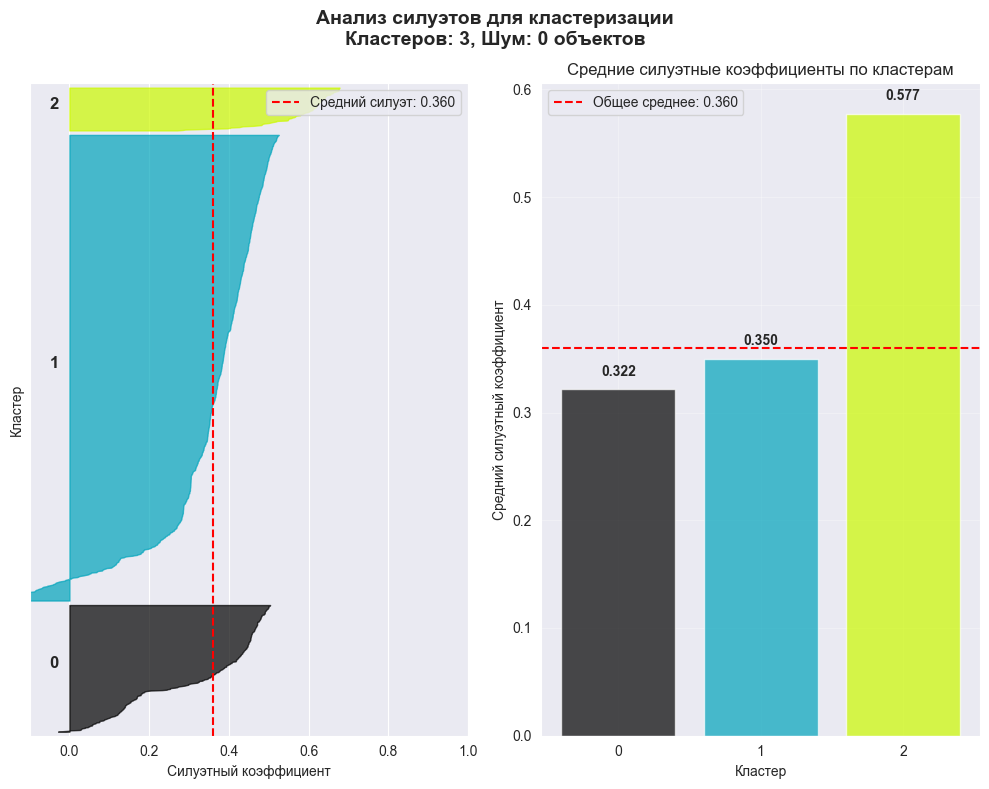


ДЕТАЛЬНАЯ СТАТИСТИКА СИЛУЭТОВ:
Общий средний силуэтный коэффициент: 0.360
Количество кластеров: 3
Размеры кластеров:
  Кластер 0: 309 объектов (20.0%)
  Кластер 1: 1134 объектов (73.3%)
  Кластер 2: 105 объектов (6.8%)


{'Silhouette': 0.359747013813173,
 'Calinski-Harabasz': 495.27536071574457,
 'Davies-Bouldin': 1.0817633007216083,
 'Avg_Intra_Cluster_Dist': np.float64(2.1303723706590434),
 'Std_Intra_Cluster_Dist': np.float64(0.3023509312636784),
 'Min_Inter_Cluster_Dist': np.float64(0.6438722039281981),
 'Avg_Inter_Cluster_Dist': np.float64(1.7165919627534592)}

In [22]:
from sklearn.mixture import GaussianMixture


gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    max_iter=200,
    tol=1e-6,
    random_state=42
)

gmm.fit(X_scaled)

labels = gmm.predict(X_scaled)

probs = gmm.predict_proba(X_scaled)

plot_silhouette_analysis(labels=labels, X_scaled=X_scaled)

calculate_internal_metrics(X_scaled, labels)

## Анализ метрик

- Silhouette = 0.3597 аналогично указывает на слабую, но существующую кластерную структуру
- Calinski-Harabasz = 495 значение выше DBSCAN, т.к. EM минимизирует внутрикластерную дисперсию и предполагает сферические кластеры
- Davies-Bouldin = 1.08 аналогично DBSCAN, но значение чуть выше
- Внутрикластерные расстояния: аналогично DBSCAN
- Межкластерные расстояния: среднее стало меньше с 2.5 -> 1.7, т.к. EM не строит произвольные границы кластеров

In [23]:
df_cluster = pd.DataFrame(X_initial).copy()
df_cluster["cluster"] = labels

cluster_profiles = df_cluster.groupby("cluster").mean()

print("=== Средние значения признаков по кластерам ===")
print(cluster_profiles.round(3))

pd.DataFrame(mappings)

=== Средние значения признаков по кластерам ===
         region  emissions   type  segment  reason
cluster                                           
0         3.000   1405.512  3.019    1.000   1.000
1         3.421    236.947  2.000    6.018   2.217
2         2.962   2788.180  1.000    1.000   1.000


,region,type,segment,reason
0,Africa,Agriculture,Bioenergy,All
1,Asia Pacific,Energy,Coking coal,Flared
2,Central and South America,Other,Gas pipelines and LNG facilities,Fugitive
3,Europe,Waste,Offshore gas,Vented
4,Middle East,NaN,Offshore oil,NaN
5,North America,NaN,Onshore gas,NaN
6,Other,NaN,Onshore oil,NaN
7,Russia & Caspian,NaN,Other from coal,NaN
8,World,NaN,Other from oil and gas,NaN
9,NaN,NaN,Satellite-detected large oil and gas emissions,NaN


Аналогично получилось 3 кластера по степени загрязнения

Регионы у кластеров смешаны, основное приходится на Америку.

Тип загрязнения у первого кластера - в этот раз другой, у второго так же энергетика и третьего - сельское хозяйство.

Сегмент у второго кластера примерно на уровне Onshore gas, что соответствует смыслу типа "Энергетика"

Аналогично у второго кластера причина загрязнения ближе к Flared - сжигание, т.к. основная причина энергетика. У остальных кластеров с высоким загрязнением находятся все варианты.

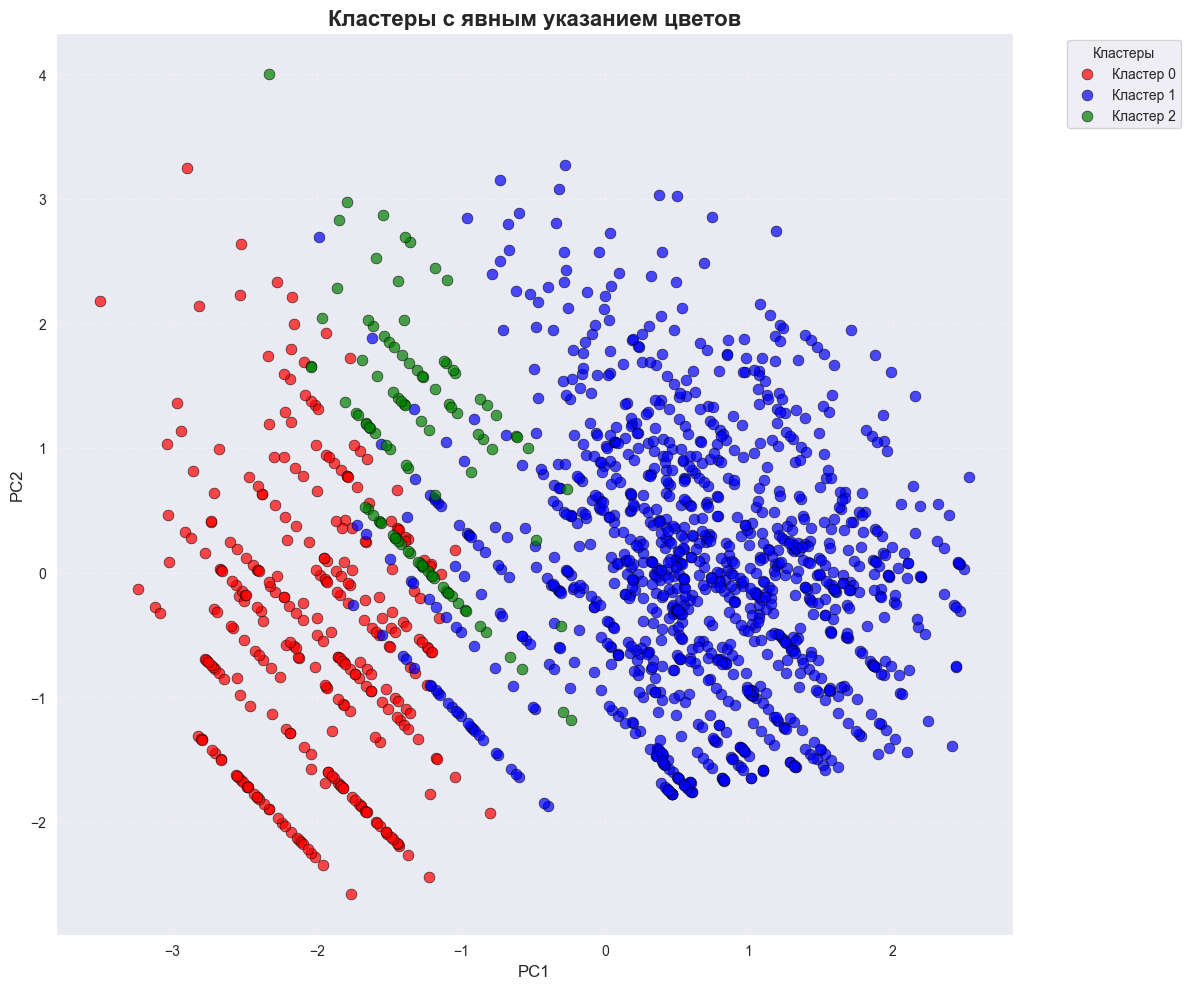

In [24]:
get_scatter(X_pca, labels)

Диаграмма рассеивания аналогично DBSCAN